### Imports

In [1]:
import sys
sys.path.append("..")

from model import SalesModel
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

DATA_DIR = Path("../data/clean")
df = pd.read_parquet(DATA_DIR / "ventas_marketing.parquet")

### Eliminar variables innecesarias

In [2]:
del_cols = [
    "fecha_venta",
    "inicio_campanha", 
    "fin_campanha",
    "precio_total",
    "ratio_ventas_costo",
    "precio_relativo",
    "nivel_precio",
    "producto",
    "costo_total_campanhas",
    "costo_email",
    "costo_rrss",
    "costo_tv"
]
df = df.drop(columns=del_cols)

### Encoding
XGBoost no se ve afectado por la escala de las variables numéricas, por lo que se dejan como están.  
Para `'producto'` se usa Target Encoding dentro del pipeline de train/test en la clase del modelo para evitar leakage.

In [3]:
le = LabelEncoder()
y = le.fit_transform(df["categoria"])
X = df.drop(columns=["categoria"])

X_train, X_test, y_train, y_test = (
    train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )
)

model = SalesModel()
model.fit(X_train, X_test, y_train, y_test, le=le)
print(model.metrics())

{'f1-score': 0.9617223972766671, 'best_params': {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}}


In [4]:
model.summary()

                   precision    recall  f1-score   support

       Decoración       0.96      0.93      0.95       227
Electrodomésticos       0.92      0.96      0.94       185
      Electrónica       1.00      1.00      1.00       188

         accuracy                           0.96       600
        macro avg       0.96      0.96      0.96       600
     weighted avg       0.96      0.96      0.96       600



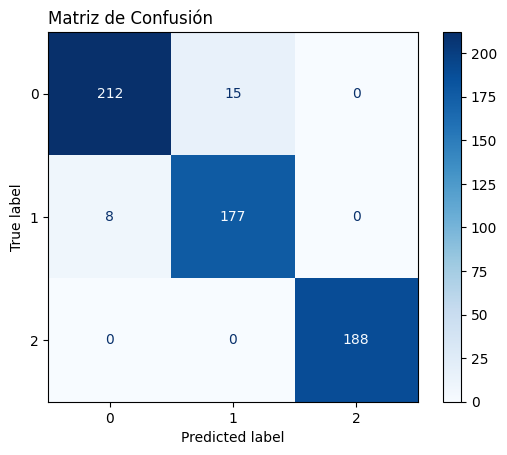

In [5]:
model.plot_confusion_matrix(X_test, y_test)

In [6]:
muestra = X_test.iloc[:10]
predicciones = model.predict(muestra)

resultado = pd.DataFrame({
    "Predicho": le.inverse_transform(predicciones),
    "Real": le.inverse_transform(y_test[:10])
})
display(resultado)


,Predicho,Real
0,Electrodomésticos,Electrodomésticos
1,Decoración,Decoración
2,Electrodomésticos,Electrodomésticos
3,Electrónica,Electrónica
4,Decoración,Decoración
5,Electrodomésticos,Electrodomésticos
6,Decoración,Decoración
7,Electrónica,Electrónica
8,Electrónica,Electrónica
9,Electrónica,Electrónica


## Análisis de resultados
---

Durante el entrenamiento del modelo se detectó la posibilidad de data leakage debido a métricas extremadamente altas en algunas pruebas. Para reducir este problema se eliminaron variables que contenían información demasiado relacionada con el target (categoria), como:

* `producto`
* `precio_relativo`
* `nivel_precio`
* `ratio_ventas_costo`
* `costo_total_campanhas`

Luego de estas modificaciones, el modelo obtuvo un accuracy y F1-score cercanos a 0.96. Aunque las métricas continúan siendo altas, esto puede explicarse por la naturaleza artificial del dataset. Al tratarse de datos generados sintéticamente, existen patrones muy consistentes entre variables como precio, cantidad y las categorías de productos, lo que facilita la clasificación para modelos como XGBoost. Por lo tanto, las métricas obtenidas no necesariamente indican leakage directo, sino una alta separabilidad entre clases generada por la estructura del dataset sintético.